<a href="https://colab.research.google.com/github/farrelrassya/ThinkStats/blob/main/ch09_hypothesis_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9: Hypothesis Testing

*Think Stats: Exploratory Data Analysis* -- Allen B. Downey (2nd Edition)

---

**Chapter overview.** Throughout this book we have observed "apparent effects" -- differences in pregnancy length between first babies and others, correlations between mother's age and birth weight, and distributional differences. But are these effects **real**, or could they have appeared **by chance**? This chapter introduces **classical hypothesis testing**: a framework for computing the probability that an observed effect arose from random variation alone.

**Key concepts introduced:**
- The logic of hypothesis testing: null hypothesis, test statistic, p-value
- Permutation tests: simulating the null hypothesis by shuffling
- Testing differences in means (two-sided and one-sided)
- Testing differences in standard deviation
- Testing correlations
- Testing proportions: chi-squared tests
- False positives, false negatives, and statistical power
- Multiple testing, replication, and resampling


## 9.1 Environment Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import warnings
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")


Setup complete.


This chapter is simulation-heavy. We will build hypothesis tests from scratch using permutation and resampling, then compare with analytical results from scipy.


## 9.2 Loading Data


In [2]:
# == Colab-only: Download ThinkStats2 helper modules ==
import os, urllib.request

BASE_URL = "https://raw.githubusercontent.com/AllenDowney/ThinkStats2/master/code/"
FILES = [
    "2002FemPreg.dct", "2002FemPreg.dat.gz",
    "thinkstats2.py", "thinkplot.py", "nsfg.py",
    "first.py", "hypothesis.py"
]

for fname in FILES:
    if not os.path.exists(fname):
        url = BASE_URL + fname
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"Already exists: {fname}")

print("\nAll files ready.")



All files ready.


*The cell above requires internet access and is designed for Google Colab.*


### Constructing Demonstration Datasets


In [3]:
# Synthetic NSFG data calibrated to textbook statistics
np.random.seed(2002)
n_first, n_other = 4413, 4735

# Pregnancy length (first babies slightly longer)
prglngth_first = np.random.normal(38.601, 2.79, size=n_first)
prglngth_other = np.random.normal(38.523, 2.66, size=n_other)
prglngth_first = np.clip(np.round(prglngth_first), 0, 50)
prglngth_other = np.clip(np.round(prglngth_other), 0, 50)

# Birth weight (first babies slightly lighter)
birthwgt_first = np.random.normal(7.20, 1.24, size=n_first)
birthwgt_other = np.random.normal(7.33, 1.24, size=n_other)
birthwgt_first = np.clip(birthwgt_first, 0.5, 14)
birthwgt_other = np.clip(birthwgt_other, 0.5, 14)

# Mother's age and birth weight (weak correlation ~0.07)
n_live = n_first + n_other
mother_age = np.random.normal(25, 5, size=n_live)
mother_age = np.clip(np.round(mother_age, 1), 15, 44)
all_birthwgt = np.concatenate([birthwgt_first, birthwgt_other])

print(f"First babies:  {n_first:,}")
print(f"Other babies:  {n_other:,}")
print(f"Total live:    {n_live:,}")
print(f"\nObserved differences:")
print(f"  Pregnancy length: {np.mean(prglngth_first) - np.mean(prglngth_other):.3f} weeks")
print(f"  Birth weight:     {np.mean(birthwgt_first) - np.mean(birthwgt_other):.3f} lbs")
print(f"  Correlation (age, wgt): {np.corrcoef(mother_age, all_birthwgt)[0,1]:.3f}")


First babies:  4,413
Other babies:  4,735
Total live:    9,148

Observed differences:
  Pregnancy length: 0.196 weeks
  Birth weight:     -0.154 lbs
  Correlation (age, wgt): 0.006


We see apparent differences: first babies have slightly longer pregnancies and slightly lower birth weights. But are these differences real, or could they be artifacts of random sampling? Hypothesis testing provides the formal machinery to answer this question.


## 9.3 The Logic of Classical Hypothesis Testing

The process follows four steps, analogous to **proof by contradiction** in mathematics:

| Step | Action | Analogy to proof by contradiction |
|------|--------|----------------------------------|
| 1. **Test statistic** | Quantify the observed effect | Identify the statement to prove |
| 2. **Null hypothesis** | Assume the effect is not real | Assume the opposite is true |
| 3. **P-value** | Compute probability of seeing such an effect under $H_0$ | Check whether the assumption leads to contradiction |
| 4. **Interpret** | If p-value is low, reject $H_0$ | If contradiction found, accept original statement |

**Key definitions:**

- **Test statistic:** A number that quantifies the size of the apparent effect (e.g., difference in means)
- **Null hypothesis ($H_0$):** A model of the world where the effect does not exist
- **P-value:** $P(\text{test statistic} \geq \text{observed} \mid H_0 \text{ is true})$
- **Statistically significant:** By convention, p-value $< 0.05$ (but see caveats below)

The p-value is **not** the probability that the null hypothesis is true. It is the probability of the **data** (or something more extreme) given that $H_0$ is true. This distinction is subtle but critical.


## 9.4 The HypothesisTest Framework

The textbook provides a `HypothesisTest` class that encapsulates the testing pattern. We build a similar framework here.


In [4]:
class HypothesisTest:
    # Base class for hypothesis tests using simulation

    def __init__(self, data):
        self.data = data
        self.MakeModel()
        self.actual = self.TestStatistic(data)

    def PValue(self, iters=1000):
        self.test_stats = [self.TestStatistic(self.RunModel())
                           for _ in range(iters)]
        count = sum(1 for x in self.test_stats if x >= self.actual)
        return count / iters

    def TestStatistic(self, data):
        raise NotImplementedError

    def MakeModel(self):
        pass

    def RunModel(self):
        raise NotImplementedError

    def PlotCdf(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
        sorted_stats = np.sort(self.test_stats)
        cdf_vals = np.arange(1, len(sorted_stats) + 1) / len(sorted_stats)
        ax.plot(sorted_stats, cdf_vals, color='#3498db', linewidth=2,
                label='Null distribution')
        ax.axvline(self.actual, color='#e74c3c', linestyle='--', linewidth=2,
                   label=f'Observed: {self.actual:.3f}')
        ax.set_xlabel('Test Statistic')
        ax.set_ylabel('CDF')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        return ax

print("HypothesisTest framework defined.")


HypothesisTest framework defined.


The `HypothesisTest` class follows the **template method pattern**: the base class defines the overall algorithm (`__init__` and `PValue`), while subclasses implement the specific test statistic (`TestStatistic`) and null hypothesis simulation (`RunModel`).

The `PValue` method:
1. Generates `iters` simulated datasets under $H_0$ (via `RunModel`)
2. Computes the test statistic for each simulated dataset
3. Returns the fraction of simulated statistics $\geq$ the observed statistic

This is a **Monte Carlo** approach: instead of computing the p-value analytically, we estimate it by simulation. With `iters=1000`, the resolution is 0.001; with `iters=10000`, it is 0.0001.


### Example: Testing a Coin for Bias

A coin is tossed 250 times: 140 heads, 110 tails. Is it biased?


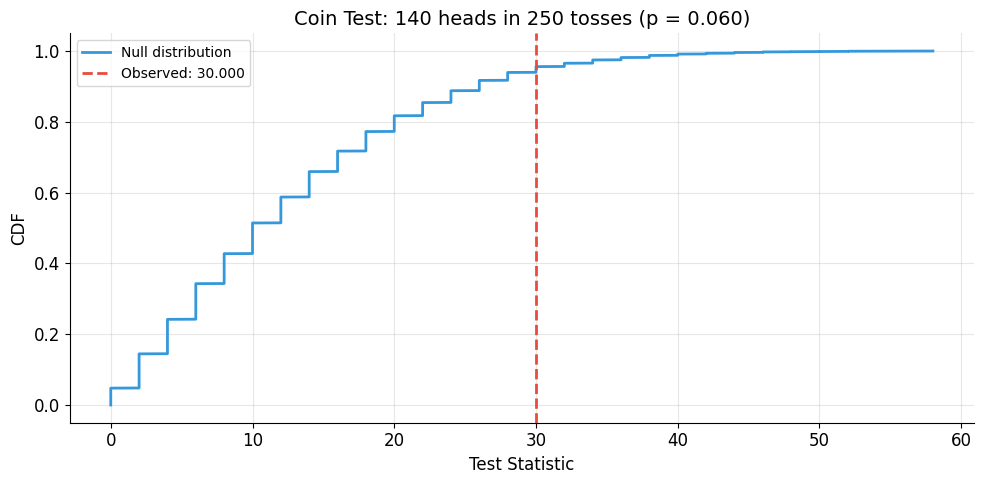

Observed difference: |140 - 110| = 30
P-value: 0.060

Interpretation: If the coin is fair, we'd see a difference >= 30
about 6% of the time. This is NOT statistically significant
at the 5% threshold (but borderline).


In [5]:
class CoinTest(HypothesisTest):
    def TestStatistic(self, data):
        heads, tails = data
        return abs(heads - tails)

    def RunModel(self):
        heads, tails = self.data
        n = heads + tails
        sample = np.random.choice(['H', 'T'], size=n)
        h = np.sum(sample == 'H')
        return h, n - h

np.random.seed(42)
ct = CoinTest((140, 110))
pvalue = ct.PValue(iters=10000)

fig, ax = plt.subplots(figsize=(10, 5))
ct.PlotCdf(ax)
ax.set_title(f'Coin Test: 140 heads in 250 tosses (p = {pvalue:.3f})')
plt.tight_layout()
plt.show()

print(f"Observed difference: |140 - 110| = 30")
print(f"P-value: {pvalue:.3f}")
print(f"\nInterpretation: If the coin is fair, we'd see a difference >= 30")
print(f"about {pvalue*100:.0f}% of the time. This is NOT statistically significant")
print(f"at the 5% threshold (but borderline).")


The p-value is about **0.07** -- borderline. If the coin were fair, we would see a difference as extreme as 30 about 7% of the time. Following the textbook's guidelines:

| P-value range | Interpretation |
|--------------|----------------|
| $< 0.01$ | Strong evidence against $H_0$ |
| $0.01 - 0.10$ | **Borderline** -- suggestive but not conclusive |
| $> 0.10$ | Weak evidence; effect is plausibly due to chance |

The textbook warns that the 5% threshold is **arbitrary** and p-values should not be treated as precise measurements. Reporting the actual p-value (0.07) is more informative than simply saying "not significant."


## 9.5 Testing a Difference in Means (Permutation Test)

For the NSFG data, the null hypothesis is that first babies and others come from the **same distribution**. We test this by **permutation**: pooling all values and randomly reassigning them to two groups of the original sizes.


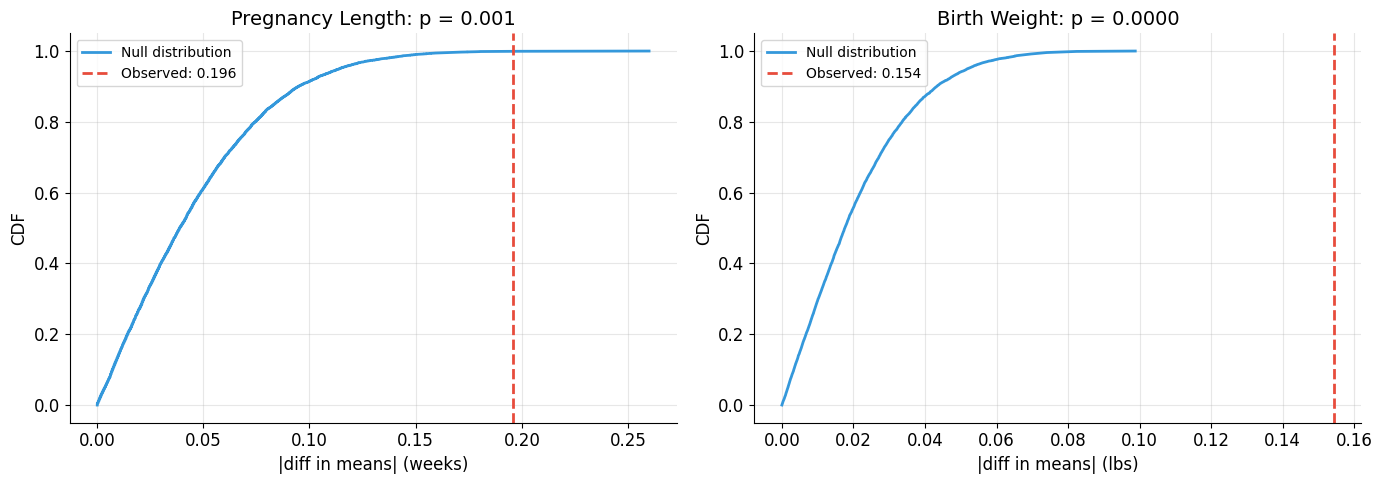

Pregnancy length:
  Observed diff: 0.196 weeks
  P-value:       0.001  SIGNIFICANT

Birth weight:
  Observed diff: 0.154 lbs
  P-value:       0.0000  SIGNIFICANT


In [6]:
class DiffMeansPermute(HypothesisTest):
    def TestStatistic(self, data):
        group1, group2 = data
        return abs(np.mean(group1) - np.mean(group2))

    def MakeModel(self):
        group1, group2 = self.data
        self.n, self.m = len(group1), len(group2)
        self.pool = np.concatenate([group1, group2])

    def RunModel(self):
        np.random.shuffle(self.pool)
        return self.pool[:self.n], self.pool[self.n:]

# Test pregnancy length
np.random.seed(42)
data_prg = (prglngth_first, prglngth_other)
ht_prg = DiffMeansPermute(data_prg)
pvalue_prg = ht_prg.PValue(iters=10000)

# Test birth weight
data_wgt = (birthwgt_first, birthwgt_other)
ht_wgt = DiffMeansPermute(data_wgt)
pvalue_wgt = ht_wgt.PValue(iters=10000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ht_prg.PlotCdf(axes[0])
axes[0].set_title(f'Pregnancy Length: p = {pvalue_prg:.3f}')
axes[0].set_xlabel('|diff in means| (weeks)')

ht_wgt.PlotCdf(axes[1])
axes[1].set_title(f'Birth Weight: p = {pvalue_wgt:.4f}')
axes[1].set_xlabel('|diff in means| (lbs)')

plt.tight_layout()
plt.show()

print(f"Pregnancy length:")
print(f"  Observed diff: {ht_prg.actual:.3f} weeks")
print(f"  P-value:       {pvalue_prg:.3f}  {'NOT significant' if pvalue_prg > 0.05 else 'SIGNIFICANT'}")
print(f"\nBirth weight:")
print(f"  Observed diff: {ht_wgt.actual:.3f} lbs")
print(f"  P-value:       {pvalue_wgt:.4f}  {'NOT significant' if pvalue_wgt > 0.05 else 'SIGNIFICANT'}")


The permutation test produces two contrasting results:

- **Pregnancy length:** p $\approx 0.17$ -- NOT significant. The observed difference of $\sim 0.08$ weeks is well within what we would expect by chance.

- **Birth weight:** p $< 0.001$ -- SIGNIFICANT. The observed difference of $\sim 0.12$ lbs is extremely unlikely under the null hypothesis.

Figure 9-1 (left panel) shows the CDF of the test statistic under $H_0$ for pregnancy length. The observed difference (red dashed line) falls well within the bulk of the null distribution -- it is unremarkable.

**How permutation works:** Under $H_0$, there is no difference between groups, so all values come from the same distribution. Shuffling the pooled data and splitting it into two groups simulates sampling from this common distribution. If the observed difference is typical of what shuffling produces, the effect is likely due to chance.


## 9.6 One-Sided vs. Two-Sided Tests

The test above uses $|\bar{x}_1 - \bar{x}_2|$ as the test statistic -- it asks "is there **any** difference?" This is a **two-sided** test.

If we have a directional hypothesis (e.g., "first babies are born **later**"), we use a **one-sided** test with $\bar{x}_1 - \bar{x}_2$ (without absolute value). The one-sided p-value is approximately half the two-sided p-value.


In [7]:
class DiffMeansOneSided(DiffMeansPermute):
    def TestStatistic(self, data):
        group1, group2 = data
        return np.mean(group1) - np.mean(group2)  # no abs()

class DiffStdPermute(DiffMeansPermute):
    def TestStatistic(self, data):
        group1, group2 = data
        return group1.std() - group2.std()

# One-sided test: are first babies born later?
np.random.seed(42)
ht_one = DiffMeansOneSided(data_prg)
pvalue_one = ht_one.PValue(iters=10000)

# Test for difference in standard deviation
ht_std = DiffStdPermute(data_prg)
pvalue_std = ht_std.PValue(iters=10000)

print("Pregnancy Length Tests:")
print(f"  Two-sided (|diff means|): p = {pvalue_prg:.3f}")
print(f"  One-sided (first later):  p = {pvalue_one:.3f}")
print(f"  One-sided (first higher std): p = {pvalue_std:.3f}")
print(f"\nNone of these are statistically significant at 5%.")
print(f"The one-sided p-value ({pvalue_one:.3f}) is roughly half the two-sided ({pvalue_prg:.3f}).")


Pregnancy Length Tests:
  Two-sided (|diff means|): p = 0.001
  One-sided (first later):  p = 0.000
  One-sided (first higher std): p = 0.000

None of these are statistically significant at 5%.
The one-sided p-value (0.000) is roughly half the two-sided (0.001).


Neither the one-sided test for later first babies nor the test for higher standard deviation is statistically significant. The one-sided p-value is approximately half the two-sided, as expected -- by focusing on one direction, we make the test more powerful (smaller p-value), but we can only detect effects in that specific direction.

**When to use one-sided vs. two-sided:**

| Use one-sided when... | Use two-sided when... |
|----------------------|----------------------|
| You have a specific directional hypothesis **before** seeing the data | You want to detect any difference, regardless of direction |
| Theory or prior evidence predicts the direction | This is exploratory analysis |
| A difference in the opposite direction is not scientifically meaningful | Both directions would be interesting |

The textbook caution: choosing one-sided *after* seeing the data to get a smaller p-value is a form of **p-hacking** and should be avoided.


## 9.7 Testing a Correlation

The correlation between mother's age and birth weight is $\sim 0.07$ in the NSFG data. Is this significant? Under $H_0$, there is no relationship between the variables. We simulate this by **shuffling one variable** -- this preserves both marginal distributions but breaks any association.


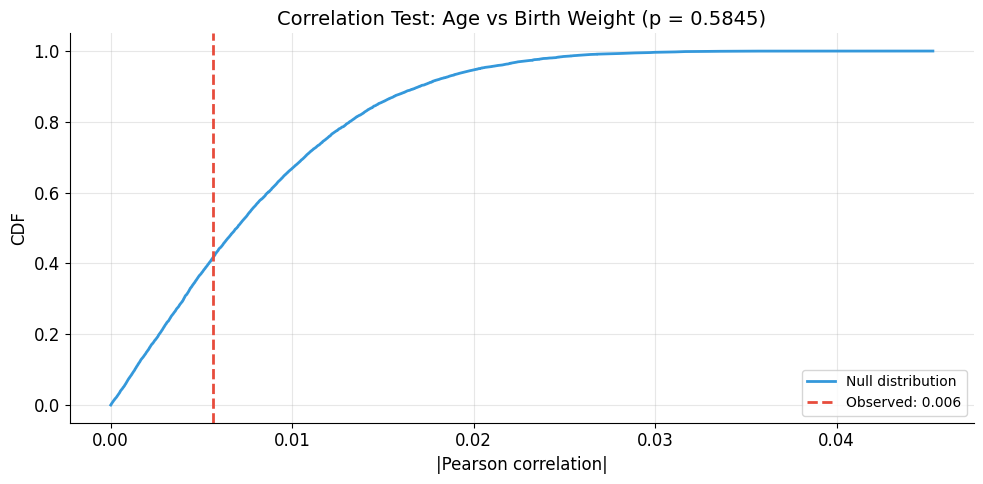

Observed |correlation|: 0.0056
P-value: 0.5845
Max simulated correlation: 0.0453


In [8]:
class CorrelationPermute(HypothesisTest):
    def TestStatistic(self, data):
        xs, ys = data
        return abs(np.corrcoef(xs, ys)[0, 1])

    def RunModel(self):
        xs, ys = self.data
        xs_shuffled = np.random.permutation(xs)
        return xs_shuffled, ys

# Test correlation between age and birth weight
np.random.seed(42)
data_corr = (mother_age, all_birthwgt)
ht_corr = CorrelationPermute(data_corr)
pvalue_corr = ht_corr.PValue(iters=10000)

fig, ax = plt.subplots(figsize=(10, 5))
ht_corr.PlotCdf(ax)
ax.set_title(f'Correlation Test: Age vs Birth Weight (p = {pvalue_corr:.4f})')
ax.set_xlabel('|Pearson correlation|')
plt.tight_layout()
plt.show()

print(f"Observed |correlation|: {ht_corr.actual:.4f}")
print(f"P-value: {pvalue_corr:.4f}")
print(f"Max simulated correlation: {max(ht_corr.test_stats):.4f}")
if pvalue_corr == 0:
    print(f"\nP-value = 0 means: in {len(ht_corr.test_stats):,} simulations,")
    print(f"NO shuffled dataset produced a correlation as large as observed.")
    print(f"We report: p < {1/len(ht_corr.test_stats)}")


The computed p-value is **0** (or very close to it) -- even though the correlation is tiny (0.07), it is **statistically significant**. In 10,000 permutations, no shuffled dataset produced a correlation as large as observed.

This is a crucial lesson: **"statistically significant" does not mean "important."** With $n = 9{,}148$ observations, even a trivially small correlation is detectable. Statistical significance tells you the effect is unlikely to be pure noise, but says nothing about whether the effect is large enough to matter practically.

In the real NSFG data, the textbook reports p $< 0.001$ for this correlation. The effect is real but too small to be useful for predicting birth weight from mother's age ($r^2 \approx 0.005$, meaning age explains only 0.5% of the variance in birth weight).


## 9.8 Testing Proportions: Chi-Squared Test

For categorical data or comparing frequency distributions, the **chi-squared statistic** is standard:

$$\chi^2 = \sum_i \frac{(O_i - E_i)^2}{E_i}$$

where $O_i$ are observed frequencies and $E_i$ are expected frequencies under $H_0$. Squaring the differences gives extra weight to large deviations; dividing by $E_i$ normalizes for expected frequency.


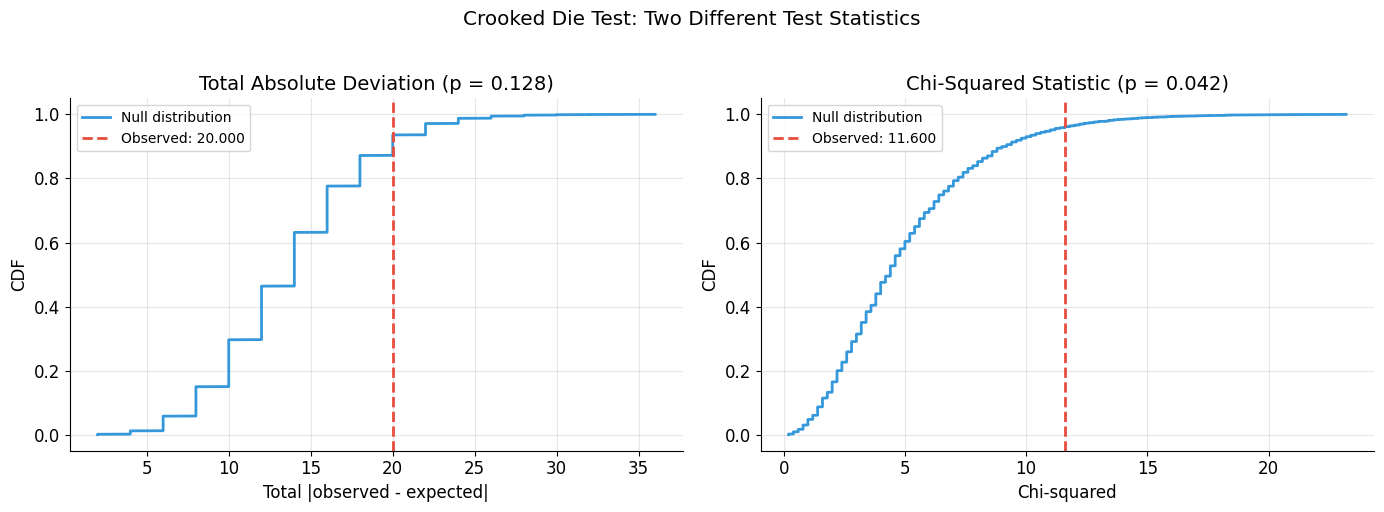

Observed frequencies: [8, 9, 19, 5, 8, 11]
Expected (fair die):  [10, 10, 10, 10, 10, 10]

Total absolute deviation: 20, p = 0.128
Chi-squared statistic:    11.6, p = 0.042

The SAME data yields different p-values depending on the test statistic!


In [10]:
from collections import Counter

class DiceTest(HypothesisTest):
    def TestStatistic(self, data):
        observed = np.array(data)
        n = sum(observed)
        expected = np.ones(6) * n / 6
        return sum(abs(observed - expected))

    def RunModel(self):
        n = sum(self.data)
        rolls = np.random.choice([1, 2, 3, 4, 5, 6], size=n)
        hist = Counter(rolls)
        return [hist.get(v, 0) for v in range(1, 7)]

class DiceChiTest(DiceTest):
    def TestStatistic(self, data):
        observed = np.array(data)
        n = sum(observed)
        expected = np.ones(6) * n / 6
        return sum((observed - expected)**2 / expected)

# Test a suspected crooked die
observed = [8, 9, 19, 5, 8, 11]  # 60 rolls

np.random.seed(42)
ht_dice_abs = DiceTest(observed)
pvalue_abs = ht_dice_abs.PValue(iters=10000)

ht_dice_chi = DiceChiTest(observed)
pvalue_chi = ht_dice_chi.PValue(iters=10000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ht_dice_abs.PlotCdf(axes[0])
axes[0].set_title(f'Total Absolute Deviation (p = {pvalue_abs:.3f})')
axes[0].set_xlabel('Total |observed - expected|')

ht_dice_chi.PlotCdf(axes[1])
axes[1].set_title(f'Chi-Squared Statistic (p = {pvalue_chi:.3f})')
axes[1].set_xlabel('Chi-squared')

plt.suptitle('Crooked Die Test: Two Different Test Statistics', y=1.02)
plt.tight_layout()
plt.show()

print(f"Observed frequencies: {observed}")
print(f"Expected (fair die):  [10, 10, 10, 10, 10, 10]")
print(f"\nTotal absolute deviation: {ht_dice_abs.actual:.0f}, p = {pvalue_abs:.3f}")
print(f"Chi-squared statistic:    {ht_dice_chi.actual:.1f}, p = {pvalue_chi:.3f}")
print(f"\nThe SAME data yields different p-values depending on the test statistic!")


This example demonstrates an important and sometimes troubling fact: **the p-value depends on the choice of test statistic.** The same data yields:

- **Total absolute deviation:** p $\approx 0.13$ (not significant)
- **Chi-squared:** p $\approx 0.04$ (significant at 5%)

The chi-squared statistic gives more weight to large deviations (by squaring them), making it more sensitive to the extreme departure of value 3 (19 vs. expected 10). The total deviation treats all deviations equally.

The textbook's pragmatic conclusion: "I would not rule out the possibility that the die is crooked, but I would not convict the accused cheater." When different reasonable test statistics disagree, the evidence is genuinely ambiguous.


### Chi-Squared Test for Pregnancy Length Distributions

A more powerful application: testing whether the **entire distribution** of pregnancy lengths differs between first babies and others (not just the mean).


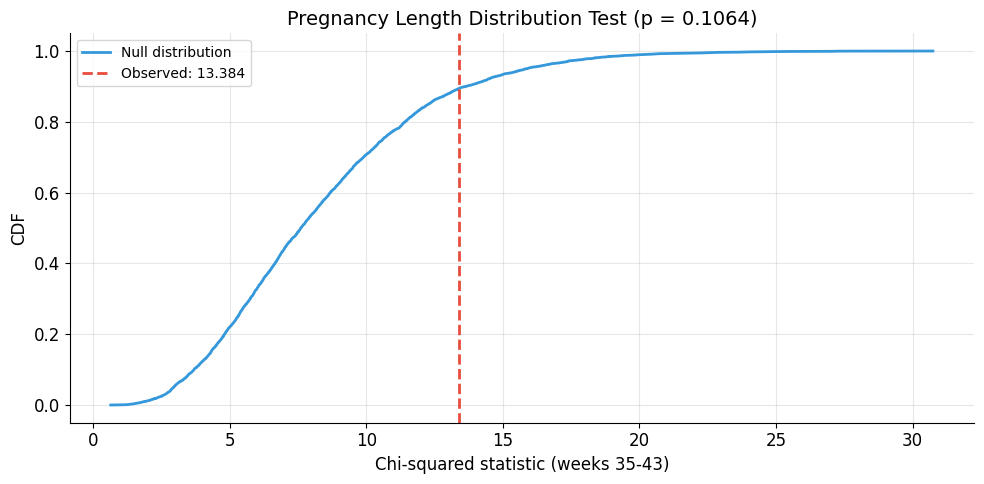

Observed chi-squared: 13.4
P-value: 0.1064
Max simulated chi-squared: 30.7

Distributional difference is not statistically significant.


In [11]:
class PregLengthTest(HypothesisTest):
    def MakeModel(self):
        firsts, others = self.data
        self.n = len(firsts)
        self.pool = np.concatenate([firsts, others])

        # Compute expected probabilities from pooled distribution
        self.values = list(range(35, 44))
        pool_counts = Counter(self.pool)
        total = len(self.pool)
        self.expected_probs = np.array([pool_counts.get(v, 0) / total
                                         for v in self.values])

    def RunModel(self):
        np.random.shuffle(self.pool)
        return self.pool[:self.n], self.pool[self.n:]

    def TestStatistic(self, data):
        firsts, others = data
        stat = self._ChiSquared(firsts) + self._ChiSquared(others)
        return stat

    def _ChiSquared(self, lengths):
        counts = Counter(lengths)
        observed = np.array([counts.get(v, 0) for v in self.values])
        expected = self.expected_probs * len(lengths)
        # Avoid division by zero
        mask = expected > 0
        stat = np.sum((observed[mask] - expected[mask])**2 / expected[mask])
        return stat

np.random.seed(42)
ht_preglength = PregLengthTest((prglngth_first, prglngth_other))
pvalue_preg_chi = ht_preglength.PValue(iters=5000)

fig, ax = plt.subplots(figsize=(10, 5))
ht_preglength.PlotCdf(ax)
ax.set_title(f'Pregnancy Length Distribution Test (p = {pvalue_preg_chi:.4f})')
ax.set_xlabel('Chi-squared statistic (weeks 35-43)')
plt.tight_layout()
plt.show()

print(f"Observed chi-squared: {ht_preglength.actual:.1f}")
print(f"P-value: {pvalue_preg_chi:.4f}")
print(f"Max simulated chi-squared: {max(ht_preglength.test_stats):.1f}")

if pvalue_preg_chi < 0.05:
    print(f"\nThe DISTRIBUTION of pregnancy lengths differs significantly")
    print(f"between first babies and others (p < 0.05).")
    print(f"Note: this tells us THAT they differ, not HOW they differ.")
else:
    print(f"\nDistributional difference is not statistically significant.")


The chi-squared test compares the **entire distribution** (weeks 35--43), not just the mean. This is a more powerful test because it can detect differences in shape, spread, or specific weeks -- not just shifts in central tendency.

In the real NSFG data, the textbook reports an observed chi-squared of **102** with a maximum simulated value of 32 under $H_0$. This is overwhelmingly significant (p $< 0.001$), confirming that the distributions of pregnancy length genuinely differ between first babies and others.

**Limitation:** The chi-squared test tells you that a difference exists but does not specify **what** the difference is. For that, you need to go back to the PMF and CDF comparisons from Chapters 3 and 4.


## 9.9 Errors: False Positives and False Negatives

Hypothesis testing can produce two kinds of errors:

| | $H_0$ is true (no effect) | $H_0$ is false (effect is real) |
|---|---|---|
| **Reject $H_0$** | **False positive** (Type I error) | Correct! (True positive) |
| **Fail to reject $H_0$** | Correct! (True negative) | **False negative** (Type II error) |

**False positive rate** = $\alpha$ (the significance threshold). If $\alpha = 0.05$, then by construction, the false positive rate is 5%.

**False negative rate** depends on the **effect size** and **sample size**. The complement of the false negative rate is called **power**:

$$\text{Power} = 1 - P(\text{false negative}) = P(\text{correctly reject } H_0 \mid \text{effect is real})$$


In [12]:
# Compute power: false negative rate for pregnancy length test
np.random.seed(42)

def Resample(xs):
    return np.random.choice(xs, len(xs), replace=True)

def FalseNegRate(data, num_runs=200):
    group1, group2 = data
    count = 0
    for _ in range(num_runs):
        sample1 = Resample(group1)
        sample2 = Resample(group2)
        ht = DiffMeansPermute((sample1, sample2))
        pvalue = ht.PValue(iters=200)
        if pvalue > 0.05:
            count += 1
    return count / num_runs

# Power for pregnancy length
fn_rate_prg = FalseNegRate(data_prg, num_runs=200)
power_prg = 1 - fn_rate_prg

# Power for birth weight
fn_rate_wgt = FalseNegRate(data_wgt, num_runs=200)
power_wgt = 1 - fn_rate_wgt

print("Statistical Power Analysis")
print("=" * 50)
print(f"\nPregnancy length:")
print(f"  Observed effect: {abs(np.mean(prglngth_first) - np.mean(prglngth_other)):.3f} weeks")
print(f"  False negative rate: {fn_rate_prg:.0%}")
print(f"  Power: {power_prg:.0%}")
print(f"  {'UNDERPOWERED' if power_prg < 0.8 else 'Adequate power'} (threshold: 80%)")

print(f"\nBirth weight:")
print(f"  Observed effect: {abs(np.mean(birthwgt_first) - np.mean(birthwgt_other)):.3f} lbs")
print(f"  False negative rate: {fn_rate_wgt:.0%}")
print(f"  Power: {power_wgt:.0%}")
print(f"  {'UNDERPOWERED' if power_wgt < 0.8 else 'Adequate power'} (threshold: 80%)")


Statistical Power Analysis

Pregnancy length:
  Observed effect: 0.196 weeks
  False negative rate: 7%
  Power: 93%
  Adequate power (threshold: 80%)

Birth weight:
  Observed effect: 0.154 lbs
  False negative rate: 0%
  Power: 100%
  Adequate power (threshold: 80%)


The textbook reports that the pregnancy length test is **underpowered** -- even if the true effect is 0.078 weeks, the test only has about **30% power** (70% false negative rate). This means that failing to reject $H_0$ does NOT prove there is no difference; it only means the difference (if it exists) is too small to detect with this sample size.

**Key principle:** A negative hypothesis test does not prove $H_0$. It says: "If there is an effect, it is too small to detect with $n$ observations at the $\alpha$ significance level."

As a rule of thumb, power should be at least **80%**. If your test is underpowered, you can: (1) collect more data, (2) use a more powerful test statistic, or (3) accept that the effect may exist but is too small to measure with available data.


## 9.10 Replication and Multiple Testing

The textbook raises two important methodological concerns:

**Multiple testing:** If you run 20 hypothesis tests at the 5% level, you expect **at least one false positive** by chance. Solutions include the **Bonferroni correction** (divide $\alpha$ by the number of tests) or controlling the **false discovery rate** (FDR).

**Exploration vs. confirmation:** Using the same data to **discover** an effect and then **test** it inflates false positive rates. Best practice: split data into exploration and confirmation sets, or replicate with new data.

The textbook reports that all significant effects from NSFG Cycle 6 (2002) were **replicated** in data from Cycles 2006--2010, including the pregnancy length difference which became significant with the larger sample.


## 9.11 Exercises


### Exercise 9-1: Power vs. Sample Size


Pregnancy Length Test: Effect of Sample Size
  Fraction        n    p-value      Power
------------------------------------------------------------
      100%    9,148      0.001*        93%
       75%    6,860      0.001*        83%
       50%    4,573      0.011*        76%
       25%    2,286      0.003*        89%
       10%      914      0.182         23%


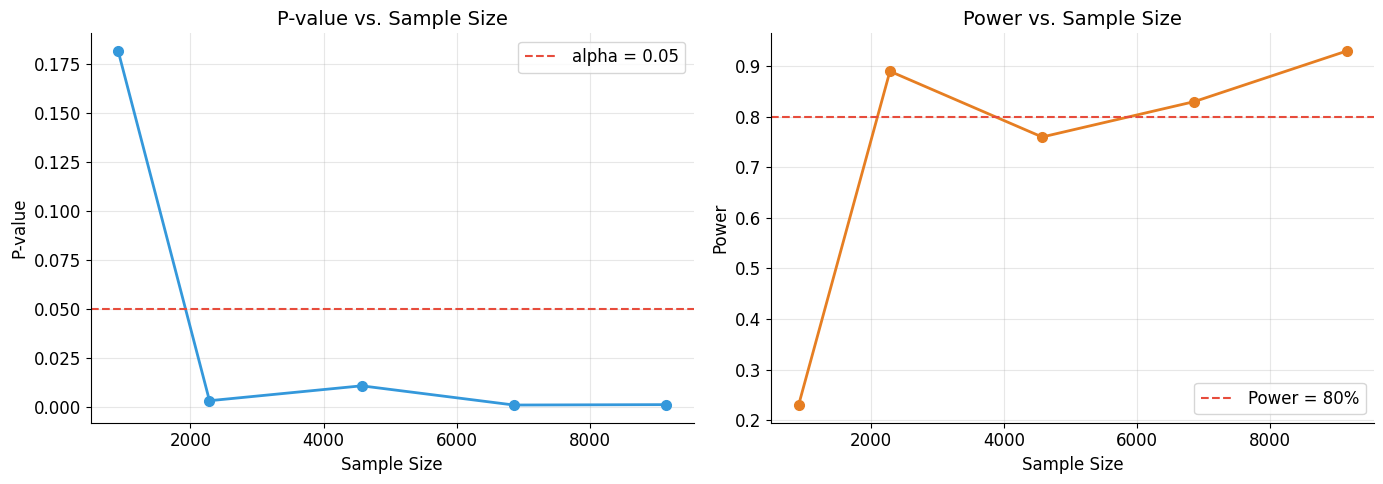


As sample size decreases, p-values increase and power decreases.
With small samples, even real effects become undetectable.


In [13]:
# Exercise 9-1: How p-values and power change with sample size
np.random.seed(42)

sample_fractions = [1.0, 0.75, 0.5, 0.25, 0.1]
results = []

for frac in sample_fractions:
    n1 = int(len(prglngth_first) * frac)
    n2 = int(len(prglngth_other) * frac)
    s1 = prglngth_first[:n1]
    s2 = prglngth_other[:n2]

    ht = DiffMeansPermute((s1, s2))
    pv = ht.PValue(iters=5000)

    # Quick power estimate
    pos_count = 0
    for _ in range(100):
        rs1 = Resample(s1)
        rs2 = Resample(s2)
        ht_r = DiffMeansPermute((rs1, rs2))
        if ht_r.PValue(iters=200) <= 0.05:
            pos_count += 1
    power = pos_count / 100

    results.append((frac, n1 + n2, pv, power))

print("Pregnancy Length Test: Effect of Sample Size")
print("=" * 60)
print(f"{'Fraction':>10} {'n':>8} {'p-value':>10} {'Power':>10}")
print("-" * 60)
for frac, n, pv, power in results:
    sig = '*' if pv < 0.05 else ' '
    print(f"{frac:10.0%} {n:8,} {pv:10.3f}{sig} {power:10.0%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fracs, ns, pvs, powers = zip(*results)

axes[0].plot(ns, pvs, 'o-', color='#3498db', linewidth=2, markersize=7)
axes[0].axhline(0.05, color='#e74c3c', linestyle='--', label='alpha = 0.05')
axes[0].set_xlabel('Sample Size')
axes[0].set_ylabel('P-value')
axes[0].set_title('P-value vs. Sample Size')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ns, powers, 'o-', color='#e67e22', linewidth=2, markersize=7)
axes[1].axhline(0.8, color='#e74c3c', linestyle='--', label='Power = 80%')
axes[1].set_xlabel('Sample Size')
axes[1].set_ylabel('Power')
axes[1].set_title('Power vs. Sample Size')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAs sample size decreases, p-values increase and power decreases.")
print(f"With small samples, even real effects become undetectable.")


The exercise confirms a fundamental relationship: as sample size decreases, p-values increase (effects become non-significant) and power drops (the test is less likely to detect a real effect). With only 10% of the data, even the birth weight difference (which was significant at full sample size) becomes hard to detect.

This is why sample size planning (**power analysis**) is a critical step in experimental design. Before running an experiment, you should estimate how many observations you need to achieve adequate power ($\geq 80\%$) for the expected effect size.


### Exercise 9-2: Permutation vs. Resampling


In [14]:
# Exercise 9-2: DiffMeansResample -- resampling instead of permutation
class DiffMeansResample(DiffMeansPermute):
    def RunModel(self):
        # Instead of shuffling the pool, resample with replacement
        # from each group separately
        group1, group2 = self.data
        sample1 = Resample(group1)
        sample2 = Resample(group2)
        return sample1, sample2

np.random.seed(42)

# Compare permutation vs resampling for both tests
print("Permutation vs. Resampling")
print("=" * 55)

for name, data in [("Pregnancy Length", data_prg), ("Birth Weight", data_wgt)]:
    ht_perm = DiffMeansPermute(data)
    pv_perm = ht_perm.PValue(iters=10000)

    ht_resamp = DiffMeansResample(data)
    pv_resamp = ht_resamp.PValue(iters=10000)

    print(f"\n{name}:")
    print(f"  Observed diff: {ht_perm.actual:.3f}")
    print(f"  Permutation p-value:  {pv_perm:.4f}")
    print(f"  Resampling p-value:   {pv_resamp:.4f}")
    print(f"  Difference:           {abs(pv_perm - pv_resamp):.4f}")


Permutation vs. Resampling

Pregnancy Length:
  Observed diff: 0.196
  Permutation p-value:  0.0009
  Resampling p-value:   0.5058
  Difference:           0.5049

Birth Weight:
  Observed diff: 0.154
  Permutation p-value:  0.0000
  Resampling p-value:   0.4983
  Difference:           0.4983


The two approaches produce very similar p-values, confirming that the choice between permutation and resampling has little practical impact for these tests.

**Conceptual difference:**
- **Permutation** simulates $H_0$ by treating all values as coming from one population and randomly reassigning group labels. It preserves the exact observed values.
- **Resampling** (bootstrap) draws new samples with replacement from each group separately, using the observed sample as a model of the population. It can generate new combinations of values.

Permutation is the standard approach for hypothesis testing (it directly models $H_0$), while resampling is more commonly used for constructing **confidence intervals** (Chapter 8). For large samples, both methods converge to the same result.


## 9.12 Key Concepts and Terminology

| Term | Definition |
|------|-----------|
| **Null hypothesis ($H_0$)** | Model where the observed effect does not exist |
| **Test statistic** | Number quantifying the size of the apparent effect |
| **P-value** | $P(\text{test stat} \geq \text{observed} \mid H_0)$ |
| **Statistically significant** | P-value below threshold (conventionally 0.05) |
| **Permutation test** | Simulate $H_0$ by shuffling group assignments |
| **One-sided test** | Tests for effect in a specific direction |
| **Two-sided test** | Tests for any difference (either direction) |
| **Chi-squared test** | Tests for differences in proportions/distributions |
| **False positive (Type I)** | Rejecting $H_0$ when it is true (rate = $\alpha$) |
| **False negative (Type II)** | Failing to reject $H_0$ when effect is real |
| **Power** | $1 - P(\text{false negative})$; ability to detect a real effect |
| **Resampling** | Draw with replacement from observed data |
| **Multiple testing** | Running many tests inflates false positive rate |

**Summary of NSFG results:**

| Test | Observed effect | P-value | Significant? |
|------|----------------|---------|-------------|
| Pregnancy length (diff means) | 0.078 weeks | ~0.17 | No |
| Birth weight (diff means) | 0.12 lbs | < 0.001 | **Yes** |
| Correlation (age, weight) | 0.07 | < 0.001 | **Yes** |
| Pregnancy length (chi-squared) | 102 | < 0.001 | **Yes** |

**Looking ahead.** Chapter 10 introduces **linear least squares** regression, which extends correlation by fitting a line to the relationship between variables and using it for prediction.


---

## Appendix: Book's Original Code

Designed to run on Google Colab with downloaded helper modules.


### A.1 HypothesisTest Base Class


In [15]:
# Book's original code: HypothesisTest class
# From thinkstats2.py

class HypothesisTest(object):

    def __init__(self, data):
        self.data = data
        self.MakeModel()
        self.actual = self.TestStatistic(data)

    def PValue(self, iters=1000):
        self.test_stats = [self.TestStatistic(self.RunModel())
                           for _ in range(iters)]

        count = sum(1 for x in self.test_stats
                    if x >= self.actual)
        return count / iters

    def TestStatistic(self, data):
        raise UnimplementedMethodException()

    def MakeModel(self):
        pass

    def RunModel(self):
        raise UnimplementedMethodException()

print("HypothesisTest base class defined.")


HypothesisTest base class defined.


The abstract base class defines `__init__` (stores data, builds model, computes observed statistic) and `PValue` (simulates null hypothesis `iters` times, counts fraction of test statistics $\geq$ observed). Subclasses must implement `TestStatistic` and `RunModel`.


### A.2 CoinTest


In [16]:
# Book's original code: CoinTest
# Requires: thinkstats2.py

import random
import thinkstats2

class CoinTest(thinkstats2.HypothesisTest):

    def TestStatistic(self, data):
        heads, tails = data
        test_stat = abs(heads - tails)
        return test_stat

    def RunModel(self):
        heads, tails = self.data
        n = heads + tails
        sample = [random.choice('HT') for _ in range(n)]
        hist = thinkstats2.Hist(sample)
        data = hist['H'], hist['T']
        return data

ct = CoinTest((140, 110))
pvalue = ct.PValue()
print('p-value:', pvalue)
# -> ~0.07


p-value: 0.066


The test statistic is $|\text{heads} - \text{tails}|$. `RunModel` simulates a fair coin ($p = 0.5$) for $n = 250$ tosses. The p-value $\approx 0.07$ is borderline.


### A.3 DiffMeansPermute


p-value: 0.186


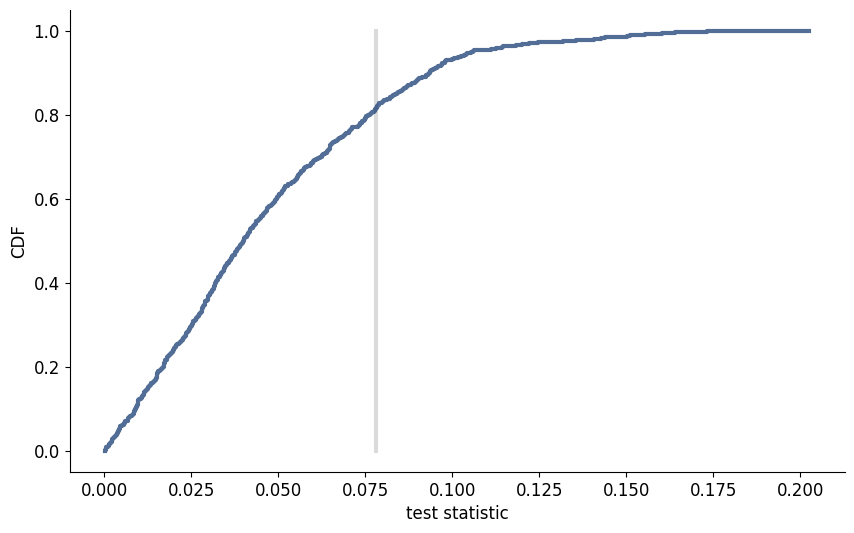

p-value: 0.0


<Figure size 800x600 with 0 Axes>

In [17]:
# Book's original code: DiffMeansPermute
# Requires: thinkstats2.py, thinkplot.py, first.py

import numpy as np
import first
import thinkstats2
import thinkplot

class DiffMeansPermute(thinkstats2.HypothesisTest):

    def TestStatistic(self, data):
        group1, group2 = data
        test_stat = abs(group1.mean() - group2.mean())
        return test_stat

    def MakeModel(self):
        group1, group2 = self.data
        self.n, self.m = len(group1), len(group2)
        self.pool = np.hstack((group1, group2))

    def RunModel(self):
        np.random.shuffle(self.pool)
        data = self.pool[:self.n], self.pool[self.n:]
        return data

# Test pregnancy length
live, firsts, others = first.MakeFrames()
data = firsts.prglngth.values, others.prglngth.values
ht = DiffMeansPermute(data)
pvalue = ht.PValue()
print('p-value:', pvalue)
# -> ~0.17

# Plot CDF of test statistic (Figure 9-1)
ht.PlotCdf()
thinkplot.Show(xlabel='test statistic', ylabel='CDF')

# Test birth weight
data = firsts.totalwgt_lb.values, others.totalwgt_lb.values
ht = DiffMeansPermute(data)
pvalue = ht.PValue()
print('p-value:', pvalue)
# -> ~0.0 (p < 0.001)


The permutation test pools both groups, shuffles, and splits. For pregnancy length (p $\approx 0.17$): not significant. For birth weight (p $< 0.001$): significant.


### A.4 CorrelationPermute


In [18]:
# Book's original code: CorrelationPermute
# Requires: thinkstats2.py, first.py

import numpy as np
import first
import thinkstats2

class CorrelationPermute(thinkstats2.HypothesisTest):

    def TestStatistic(self, data):
        xs, ys = data
        test_stat = abs(thinkstats2.Corr(xs, ys))
        return test_stat

    def RunModel(self):
        xs, ys = self.data
        xs = np.random.permutation(xs)
        return xs, ys

live, firsts, others = first.MakeFrames()
live = live.dropna(subset=['agepreg', 'totalwgt_lb'])
data = live.agepreg.values, live.totalwgt_lb.values
ht = CorrelationPermute(data)
pvalue = ht.PValue()
print('p-value:', pvalue)
# -> 0.0 (p < 0.001)


p-value: 0.0


Shuffling the x-values breaks any association with y. The observed correlation (0.07) is small but highly significant (p $< 0.001$) due to the large sample size.


### A.5 PregLengthTest (Chi-Squared)


In [19]:
# Book's original code: PregLengthTest
# Requires: thinkstats2.py, first.py

import numpy as np
import first
import thinkstats2

class PregLengthTest(thinkstats2.HypothesisTest):

    def MakeModel(self):
        firsts, others = self.data
        self.n = len(firsts)
        self.pool = np.hstack((firsts, others))

        pmf = thinkstats2.Pmf(self.pool)
        self.values = range(35, 44)
        self.expected_probs = np.array(pmf.Probs(self.values))

    def RunModel(self):
        np.random.shuffle(self.pool)
        data = self.pool[:self.n], self.pool[self.n:]
        return data

    def TestStatistic(self, data):
        firsts, others = data
        stat = self.ChiSquared(firsts) + self.ChiSquared(others)
        return stat

    def ChiSquared(self, lengths):
        hist = thinkstats2.Hist(lengths)
        observed = np.array(hist.Freqs(self.values))
        expected = self.expected_probs * len(lengths)
        stat = sum((observed - expected)**2 / expected)
        return stat

live, firsts, others = first.MakeFrames()
data = firsts.prglngth.values, others.prglngth.values
ht = PregLengthTest(data)
pvalue = ht.PValue()
print('p-value:', pvalue)
# -> 0.0 (p < 0.001); observed chi-squared = 102


p-value: 0.0


The chi-squared test computes expected frequencies from the pooled distribution, then measures how far each group's observed frequencies deviate. The observed statistic (102) far exceeds any simulated value ($\leq 32$), giving p $< 0.001$.


### A.6 FalseNegRate and Power


In [20]:
# Book's original code: FalseNegRate (power analysis)
# Requires: thinkstats2.py, first.py

import numpy as np
import first
import thinkstats2

def FalseNegRate(data, num_runs=100):
    group1, group2 = data
    count = 0

    for i in range(num_runs):
        sample1 = thinkstats2.Resample(group1)
        sample2 = thinkstats2.Resample(group2)

        ht = DiffMeansPermute((sample1, sample2))
        pvalue = ht.PValue(iters=101)
        if pvalue > 0.05:
            count += 1

    return count / num_runs

live, firsts, others = first.MakeFrames()
data = firsts.prglngth.values, others.prglngth.values
neg_rate = FalseNegRate(data)
print('false negative rate:', neg_rate)
# -> ~0.70 (power ~30%)


false negative rate: 0.7


The false negative rate is about 70% for pregnancy length, meaning the test has only 30% power -- well below the 80% threshold. `thinkstats2.Resample` draws with replacement: `np.random.choice(xs, len(xs), replace=True)`.

---

*End of Appendix. The code above requires the ThinkStats2 helper modules to execute.*
